# Este notebook realiza uma análise exploratória dos dados de avaliações de produtos da Amazon.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

df = pd.read_csv("../data/processed/dados_limpos.csv")

df.head()

,Search Query,Product Title,Link,Review,Sentiment
0,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,Com a necessidade de comprar um celular custo ...,positivo
1,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,Minha experiência de 10 dias de uso com o Xiao...,positivo
2,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,"Smartphone de qualidade como já esperava, boas...",positivo
3,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,atendeu mto minhas expectativas. Antes eu usa...,positivo
4,smartphone,Smartphone Xiaomi Note 12 4G 128GB 6GB Ram (VE...,https://www.amazon.com.br/dp/B0BZ7RJDHD,"Gostei muito do celular, tem resposta rápida e...",positivo


Bom: 16152
Ruim: 10085


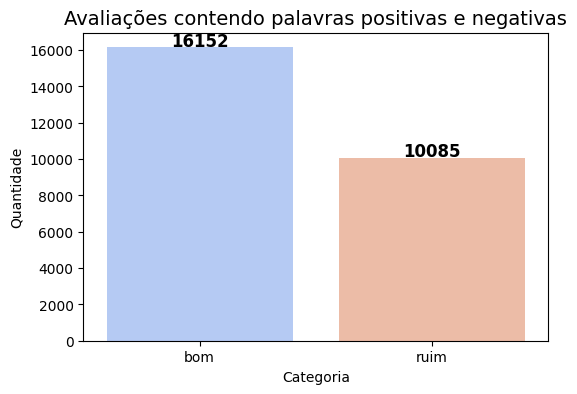

In [31]:
positivas = [
    "bom", "boa", "ótimo", "otimo", "excelente", "gostei", "maravilhoso",
    "perfeito", "recomendo", "amei", "funciona", "qualidade"
]

negativas = [
    "ruim", "péssimo", "pessimo", "horrível", "horrivel", "não gostei",
    "nao gostei", "terrível", "terrivel", "decepcionado", "lixo"
]

def contar_sentimentos_por_palavras(df):
    contagem_bom = 0
    contagem_ruim = 0

    for texto in df["Review"].astype(str).str.lower():

        if any(p in texto for p in positivas):
            contagem_bom += 1

        if any(n in texto for n in negativas):
            contagem_ruim += 1

    return contagem_bom, contagem_ruim


bom, ruim = contar_sentimentos_por_palavras(df)
print("Bom:", bom)
print("Ruim:", ruim)

df_plot = pd.DataFrame({
    "Categoria": ["bom", "ruim"],
    "Quantidade": [bom, ruim]
})

plt.figure(figsize=(6,4))
ax = sns.barplot(data=df_plot, x="Categoria", y="Quantidade", hue="Categoria", palette="coolwarm", legend=False)


plt.title("Avaliações contendo palavras positivas e negativas", fontsize=14)
plt.xlabel("Categoria")
plt.ylabel("Quantidade")

# Adicionar os números acima das barras
for i, v in enumerate(df_plot["Quantidade"]):
    ax.text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

plt.show()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\lucas\AppData\Local\Temp\ipykernel_9292\3252678511.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequencias, y=palavras_plot, palette="mako", legend=False)


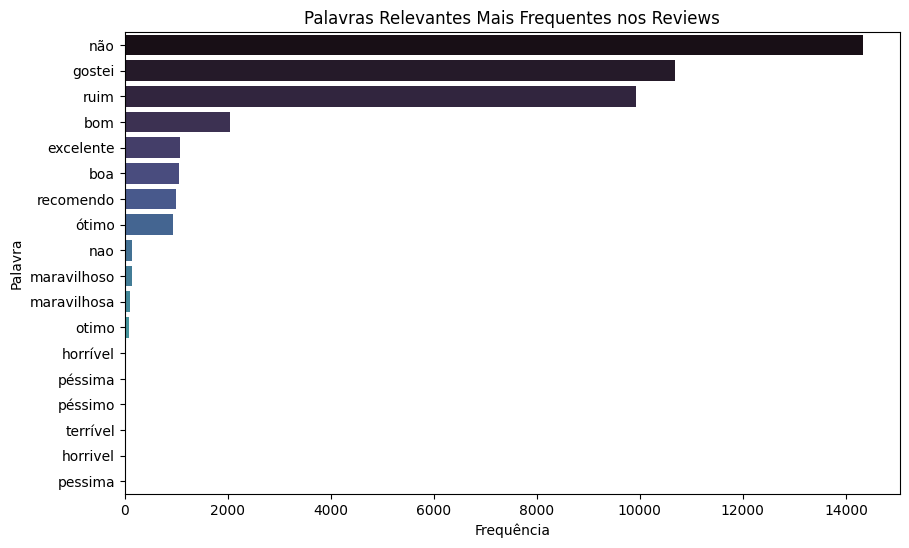

In [32]:
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Baixa stopwords se necessário
nltk.download("stopwords")
stopwords_pt = set(nltk.corpus.stopwords.words("portuguese"))

# Lista de palavras  relevantes
palavras_relevantes = [
    "gostei", "ruim", "bom", "boa", "ótimo", "otimo", "excelente",
    "péssimo", "péssima", "pessimo", "pessima", "horrivel", "horrível",
    "terrível", "maravilhoso", "maravilhosa", "recomendo", "não", "nao"
]

textos = " ".join(df["Review"].astype(str).tolist()).lower()
textos = re.sub(r"[^a-zA-Zà-úÀ-Ú ]", " ", textos)  # remove numeros e símbolos
palavras = textos.split()

palavras_filtradas = [p for p in palavras if p in palavras_relevantes]

# Contar as palavras importantes
contagem = Counter(palavras_filtradas)
top_palavras = contagem.most_common(20)

palavras_plot = [p[0] for p in top_palavras]
frequencias = [p[1] for p in top_palavras]

plt.figure(figsize=(10,6))
sns.barplot(x=frequencias, y=palavras_plot, palette="mako", legend=False)
plt.title("Palavras Relevantes Mais Frequentes nos Reviews")
plt.xlabel("Frequência")
plt.ylabel("Palavra")
plt.show()
